# Session 7 — Unsupervised Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-07-unsupervised.ipynb)

**ML/AI & GenAI Internship** · Clustering · k-Means, Hierarchical, DBSCAN · Association Rules · Dimensionality Reduction

---

## How to use this notebook

**Everything so far had an answer key. From here there is none.** Nobody can tell you your clustering is "correct" — which makes judgement, not code, the hard part.

| # | Topic |
|---|---|
| 1 | What unsupervised learning is |
| 2 | k-Means and choosing k |
| 3 | Hierarchical clustering and DBSCAN |
| 4 | Association Rule Mining |
| 5 | Dimensionality Reduction |

Exercises, MCQs and tasks: [Session 7 guide](../sessions/session-07-unsupervised.md).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"
print("ready")

ready


---
# 1. What unsupervised learning is

🧠 **A box of loose photographs.** Supervised learning is a box already sorted into labelled envelopes, and you learn to file new photos correctly. Unsupervised learning is an **unsorted** box: you decide the piles yourself. Two people would make different piles, and neither would be wrong.

| Family | Question it answers |
|---|---|
| **Clustering** | *What natural groups exist?* |
| **Association rules** | *What goes with what?* |
| **Dimensionality reduction** | *Can I see this in 2D?* |

> **The hard part is not the code — it is knowing whether the answer is useful.**

In [2]:
mall = pd.read_csv(BASE + "clustering/Mall_Customers.csv")
print(mall.shape)
print(mall.head())
print("\nNobody labelled these customers.")
print("The segments do not exist until you find them.")

(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Nobody labelled these customers.
The segments do not exist until you find them.


In [3]:
# The whole difference is the missing y.
#
#   clf = LogisticRegression().fit(X, y)     supervised   - needs y
#   km  = KMeans(n_clusters=5).fit(X)        unsupervised - NO y anywhere
#
# So how do you judge it? Silhouette: is each point closer to its own
# group than to the nearest other group?  Runs from -1 to 1.

X = mall[["Annual Income (k$)", "Spending Score (1-100)"]]
Xs = StandardScaler().fit_transform(X)
print("scaled shape:", Xs.shape)
print("\n  above 0.5   strong, well-separated groups")
print("  0.25 - 0.5  reasonable structure")
print("  below 0.25  weak - the groups may not be real")

scaled shape: (200, 2)

  above 0.5   strong, well-separated groups
  0.25 - 0.5  reasonable structure
  below 0.25  weak - the groups may not be real


---
# 2. k-Means and choosing k

🧠 **k food stalls at a festival.** Drop k stalls at random. Everyone walks to their nearest stall. Each stall moves to the middle of its own crowd. People re-choose. Repeat until nothing moves.

**You must decide how many stalls to put out before you start.** That is k, and the algorithm cannot choose it for you.

> ⚠️ **Always scale before k-Means.** It measures distance — the same reason kNN needed it in Session 5.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = list(range(2, 9))
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))
    print(f"k={k}  inertia {km.inertia_:8.2f}   silhouette {sil[-1]:.4f}")

print("\nINERTIA ALWAYS FALLS as k rises - at k=200 every customer is their")
print("own cluster and inertia is zero. That is why inertia alone can never")
print("choose k. You look for the BEND.")
print("Silhouette does have a peak. Here both point to k=5.")

k=2  inertia   269.69   silhouette 0.3213
k=3  inertia   157.70   silhouette 0.4666
k=4  inertia   108.92   silhouette 0.4939
k=5  inertia    65.57   silhouette 0.5547
k=6  inertia    55.06   silhouette 0.5399
k=7  inertia    44.86   silhouette 0.5281
k=8  inertia    37.23   silhouette 0.4552

INERTIA ALWAYS FALLS as k rises - at k=200 every customer is their
own cluster and inertia is zero. That is why inertia alone can never
choose k. You look for the BEND.
Silhouette does have a peak. Here both point to k=5.


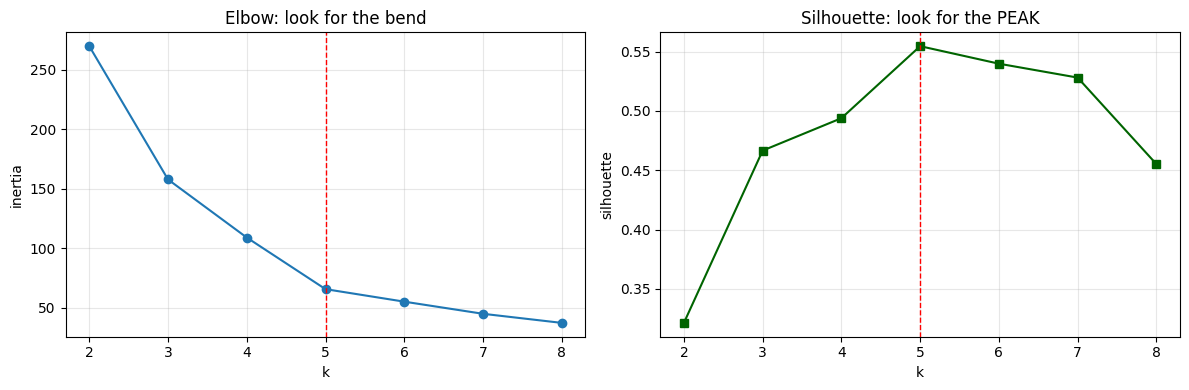

Two independent methods agreeing is the strongest evidence you get
without labels.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, inertia, "o-"); ax1.set_title("Elbow: look for the bend")
ax1.set_xlabel("k"); ax1.set_ylabel("inertia"); ax1.grid(alpha=.3)
ax1.axvline(5, color="red", ls="--", lw=1)

ax2.plot(ks, sil, "s-", color="darkgreen"); ax2.set_title("Silhouette: look for the PEAK")
ax2.set_xlabel("k"); ax2.set_ylabel("silhouette"); ax2.grid(alpha=.3)
ax2.axvline(5, color="red", ls="--", lw=1)
plt.tight_layout(); plt.show()

print("Two independent methods agreeing is the strongest evidence you get")
print("without labels.")

In [6]:
# The deliverable is NOT the score - it is the named segments.
km5 = KMeans(n_clusters=5, n_init=10, random_state=42).fit(Xs)
mall["cluster"] = km5.labels_

profile = mall.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
profile["customers"] = mall.groupby("cluster").size()
def band(v, lo, hi):
    return "low" if v < lo else "high" if v > hi else "mid"

inc_lo, inc_hi = X["Annual Income (k$)"].quantile([.33, .67])
spd_lo, spd_hi = X["Spending Score (1-100)"].quantile([.33, .67])

LABELS = {("high", "high"): "Target",    ("high", "low"): "Careful",
          ("low",  "high"): "Careless",  ("low",  "low"): "Sensible"}

names = {}
for c, row in profile.iterrows():
    i = band(row["Annual Income (k$)"], inc_lo, inc_hi)
    s_ = band(row["Spending Score (1-100)"], spd_lo, spd_hi)
    names[c] = LABELS.get((i, s_), "Standard")     # anything mid = the bulk
profile["name"] = pd.Series(names)
print(profile.to_string())
print("\nA cluster you cannot NAME is a cluster you cannot use.")

         Annual Income (k$)  Spending Score (1-100)  customers      name
cluster                                                                 
0                      55.3                    49.5         81  Standard
1                      86.5                    82.1         39    Target
2                      25.7                    79.4         22  Careless
3                      88.2                    17.1         35   Careful
4                      26.3                    20.9         23  Sensible



A cluster you cannot NAME is a cluster you cannot use.


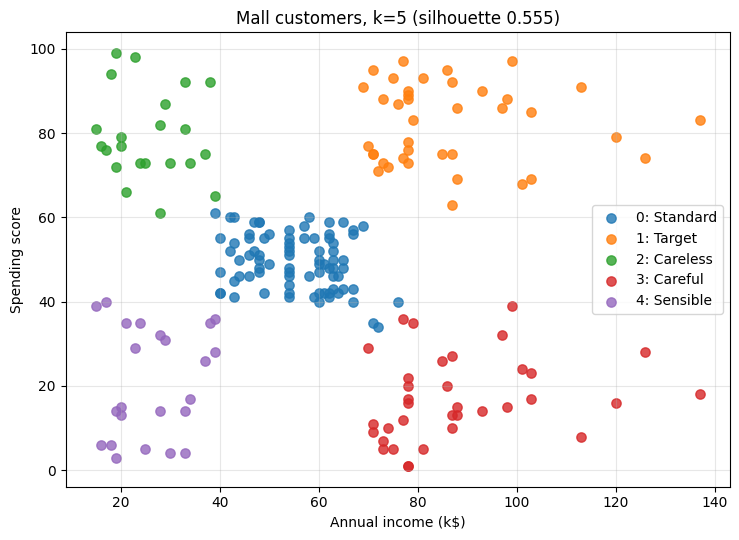

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for c in sorted(mall.cluster.unique()):
    sub = mall[mall.cluster == c]
    ax.scatter(sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
               s=45, alpha=.8, label=f"{c}: {names[c]}")
ax.set_xlabel("Annual income (k$)"); ax.set_ylabel("Spending score")
ax.set_title(f"Mall customers, k=5 (silhouette {sil[ks.index(5)]:.3f})")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# 3. Hierarchical clustering and DBSCAN

k-Means has two real limitations: **you must choose k in advance**, and **it only finds round blobs**.

🧠 **Hierarchical — a family tree built upwards.** Everyone starts alone; repeatedly join the two closest groups. The full history is the **dendrogram**, and you cut it at whatever height you like — choosing k *after* seeing the structure.

🧠 **DBSCAN — finding towns from a map of houses at night.** Dense packing means a town. Isolated houses in the countryside belong to no town, and DBSCAN is the only algorithm here that will **say so** (label `-1` = noise).

| | k-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| Choose k in advance? | **Yes** | No | **No** |
| Finds odd shapes? | No | Somewhat | **Yes** |
| Handles outliers? | No | No | **Yes — labels them noise** |
| Scales to large data? | **Yes** | Poorly | Moderately |

In [8]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN

km = KMeans(n_clusters=5, n_init=10, random_state=42).fit(Xs)
ag = AgglomerativeClustering(n_clusters=5).fit(Xs)
db = DBSCAN(eps=0.4, min_samples=5).fit(Xs)
n_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)

print(f"{'k-Means k=5':<22}{silhouette_score(Xs, km.labels_):.4f}")
print(f"{'Hierarchical k=5':<22}{silhouette_score(Xs, ag.labels_):.4f}")
print(f"{'DBSCAN eps=0.4':<22}{silhouette_score(Xs, db.labels_):.4f}"
      f"   ({n_db} clusters, {(db.labels_ == -1).sum()} noise points)")

print("\nk-Means and hierarchical agree almost EXACTLY. Two different")
print("algorithms finding the same structure is strong evidence it is real.")
print("\nDBSCAN does worse here, and that is EXPECTED: these segments are")
print("round blobs, which is exactly what k-Means is built for.")
print("Using the fancier algorithm because it is fancier is a mistake.")

k-Means k=5           0.5547
Hierarchical k=5      0.5538
DBSCAN eps=0.4        0.4133   (4 clusters, 15 noise points)

k-Means and hierarchical agree almost EXACTLY. Two different
algorithms finding the same structure is strong evidence it is real.

DBSCAN does worse here, and that is EXPECTED: these segments are
round blobs, which is exactly what k-Means is built for.
Using the fancier algorithm because it is fancier is a mistake.


In [9]:
# DBSCAN's eps is a real burden, not a free lunch.
print(f"{'eps':>5}{'clusters':>10}{'noise':>8}{'silhouette':>13}")
print("-" * 36)
for eps in [0.2, 0.3, 0.4, 0.5, 0.6]:
    lab = DBSCAN(eps=eps, min_samples=5).fit_predict(Xs)
    n = len(set(lab)) - (1 if -1 in lab else 0)
    s = f"{silhouette_score(Xs, lab):.4f}" if n > 1 else "     -"
    print(f"{eps:>5}{n:>10}{(lab == -1).sum():>8}{s:>13}")

print("\nSmall eps fragments the data and calls most of it noise.")
print("Large eps melts everything into one blob.")
print("DBSCAN removes the burden of choosing k and hands you eps instead.")

  eps  clusters   noise   silhouette
------------------------------------
  0.2         7      77       0.1406
  0.3         7      35       0.3161
  0.4         4      15       0.4133
  0.5         2       8       0.3504
  0.6         1       5            -

Small eps fragments the data and calls most of it noise.
Large eps melts everything into one blob.
DBSCAN removes the burden of choosing k and hands you eps instead.


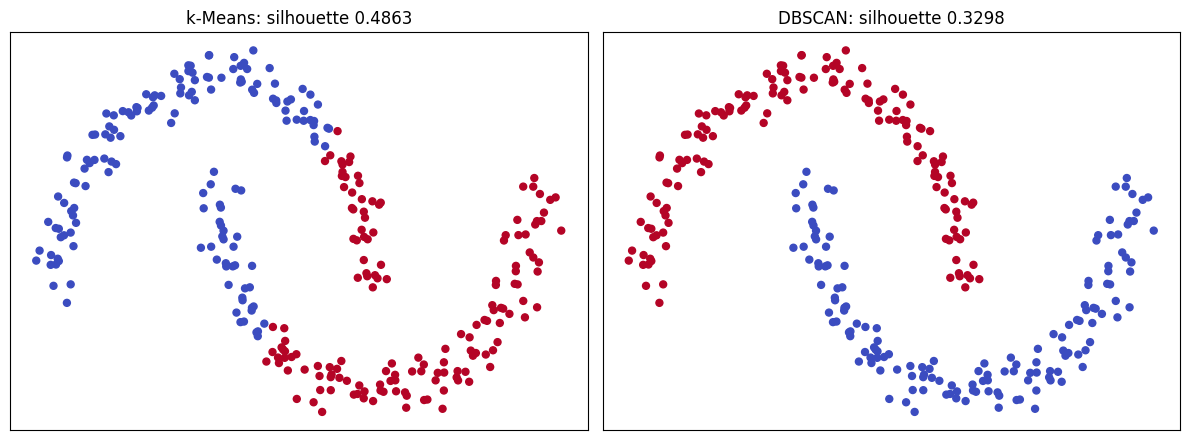

k-Means silhouette 0.4863   sliced both crescents in half - WRONG
DBSCAN  silhouette 0.3298   found the two crescents  - RIGHT

READ THAT AGAIN. The metric prefers the WRONG answer.

Silhouette is built on distance to a cluster centre, so it quietly
assumes clusters are round. A crescent's own centre is OUTSIDE the
crescent. The metric is biased toward exactly what k-Means produces.

This is why you ALWAYS PLOT your clusters. When the plot and the
metric disagree, the plot wins - and you should be able to say why.


In [10]:
# Where DBSCAN wins - AND where the metric lies.
from sklearn.datasets import make_moons

Xm, _ = make_moons(n_samples=300, noise=0.06, random_state=42)
kl = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Xm)
dl = DBSCAN(eps=0.3, min_samples=5).fit_predict(Xm)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.scatter(Xm[:, 0], Xm[:, 1], c=kl, cmap="coolwarm", s=25)
a1.set_title(f"k-Means: silhouette {silhouette_score(Xm, kl):.4f}")
a2.scatter(Xm[:, 0], Xm[:, 1], c=dl, cmap="coolwarm", s=25)
a2.set_title(f"DBSCAN: silhouette {silhouette_score(Xm, dl):.4f}")
for a in (a1, a2): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print(f"k-Means silhouette {silhouette_score(Xm, kl):.4f}   sliced both crescents in half - WRONG")
print(f"DBSCAN  silhouette {silhouette_score(Xm, dl):.4f}   found the two crescents  - RIGHT")
print()
print("READ THAT AGAIN. The metric prefers the WRONG answer.")
print()
print("Silhouette is built on distance to a cluster centre, so it quietly")
print("assumes clusters are round. A crescent's own centre is OUTSIDE the")
print("crescent. The metric is biased toward exactly what k-Means produces.")
print()
print("This is why you ALWAYS PLOT your clusters. When the plot and the")
print("metric disagree, the plot wins - and you should be able to say why.")

---
# 4. Association Rule Mining

🧠 **Watching a supermarket's trolleys all day.** You notice bread and butter keep turning up together. But so do bread and *shopping bags* — because almost every trolley has a bag. **The first is a real pattern; the second is just popularity.** Telling those apart is the entire point.

For a rule **A → B**:

| Number | Question |
|---|---|
| **Support** | *How often does this happen at all?* |
| **Confidence** | *When A happens, how often does B?* |
| **Lift** | ***Is this more than B's popularity alone?*** |

- **Lift > 1** — A genuinely makes B more likely. **Interesting.**
- **Lift ≈ 1** — no relationship; B is just common.
- **Lift < 1** — A makes B *less* likely.

In [11]:
# 500 shopping baskets, with TWO RULES DELIBERATELY PLANTED.
from itertools import combinations

rng = np.random.default_rng(7)
items = ["bread", "milk", "eggs", "butter", "jam", "tea", "coffee", "sugar", "rice", "oil"]

baskets = []
for _ in range(500):
    b = {str(x) for x in rng.choice(items, size=rng.integers(2, 5), replace=False)}
    if "bread" in b and rng.random() < .75: b.add("butter")     # planted rule 1
    if "tea"   in b and rng.random() < .70: b.add("sugar")      # planted rule 2
    baskets.append(b)

print("baskets:", len(baskets))
for b in baskets[:4]:
    print("  ", sorted(b))

baskets: 500
   ['jam', 'oil', 'rice', 'sugar', 'tea']
   ['oil', 'sugar']
   ['coffee', 'milk', 'sugar']
   ['eggs', 'oil', 'rice', 'sugar']


In [12]:
def support(s):
    return sum(1 for b in baskets if s <= b) / len(baskets)

def rule(A, B):
    conf = support(A | B) / support(A)
    return support(A | B), conf, conf / support(B)

s, c, l = rule({"bread"}, {"butter"})
print(f"bread -> butter    support {s:.3f}   confidence {c:.3f}   lift {l:.2f}")
print()
print("Now the TRAP - high confidence, lift near 1:")
for other in ["milk", "eggs", "oil"]:
    s2, c2, l2 = rule({"bread"}, {other})
    print(f"bread -> {other:<7}   support {s2:.3f}   confidence {c2:.3f}   lift {l2:.2f}")
print()
print("A rule with lift near 1 tells you NOTHING: the consequent is simply")
print("common, and the antecedent did not change its odds.")

bread -> butter    support 0.232   confidence 0.806   lift 1.68

Now the TRAP - high confidence, lift near 1:
bread -> milk      support 0.082   confidence 0.285   lift 0.96
bread -> eggs      support 0.060   confidence 0.208   lift 0.71
bread -> oil       support 0.080   confidence 0.278   lift 0.94

A rule with lift near 1 tells you NOTHING: the consequent is simply
common, and the antecedent did not change its odds.


In [13]:
# Apriori. The one idea it rests on:
#   if {bread, butter} is rare, {bread, butter, jam} CANNOT be common.
# So you never test it. That single prune makes the search feasible.

MIN_SUP, MIN_CONF = 0.05, 0.5

freq = {frozenset([i]) for i in items if support({i}) >= MIN_SUP}
all_freq, k = set(freq), 2
while freq and k <= 3:
    cand = {a | b for a in freq for b in freq if len(a | b) == k}   # grow by one
    freq = {c for c in cand if support(set(c)) >= MIN_SUP}         # keep frequent
    all_freq |= freq
    k += 1
print("frequent itemsets found:", len(all_freq))

rules = []
for s_ in all_freq:
    if len(s_) < 2: continue
    for r in range(1, len(s_)):
        for ante in combinations(sorted(s_), r):
            A_, B_ = set(ante), set(s_) - set(ante)
            conf = support(set(s_)) / support(A_)
            if conf >= MIN_CONF:
                rules.append((sorted(A_), sorted(B_), support(set(s_)), conf, conf / support(B_)))

rules.sort(key=lambda r: -r[4])
print(f"\n{'antecedent':<22}{'consequent':<14}{'sup':>7}{'conf':>7}{'lift':>7}")
print("-" * 57)
for a, b, sp, cf, lf in rules[:8]:
    print(f"{','.join(a):<22}{','.join(b):<14}{sp:>7.3f}{cf:>7.3f}{lf:>7.2f}")

print("\nApriori recovered the planted bread->butter rule.")
print("SORT BY LIFT, not confidence: the highest-confidence rules are")
print("often just about popular items.")
print("\nIn production: pip install mlxtend -> apriori(), association_rules().")
print("But you now know what those functions do.")

frequent itemsets found: 62

antecedent            consequent        sup   conf   lift
---------------------------------------------------------
butter,jam            bread           0.068  0.567   1.97
butter,oil            bread           0.060  0.517   1.80
bread,jam             butter          0.068  0.850   1.77
butter,rice           bread           0.056  0.509   1.77
bread,rice            butter          0.056  0.848   1.77
rice,tea              sugar           0.056  0.824   1.75
bread                 butter          0.232  0.806   1.68
butter,tea            sugar           0.086  0.782   1.66

Apriori recovered the planted bread->butter rule.
SORT BY LIFT, not confidence: the highest-confidence rules are
often just about popular items.

In production: pip install mlxtend -> apriori(), association_rules().
But you now know what those functions do.


---
# 5. Dimensionality Reduction

🧠 **The shadow of a teapot.** A teapot is three-dimensional; its shadow is flat. **A well-chosen angle casts a shadow you can still recognise as a teapot; a bad angle casts a blob.** PCA finds the angle that keeps the most information.

| Tool | Best for | Caution |
|---|---|---|
| **PCA** | Fast, linear, good default | Only straight-line structure |
| **t-SNE** | Beautiful cluster pictures | Distances *between* clusters are meaningless |
| **UMAP** | Faster, keeps more global shape | Extra install |

> ⚠️ **Session 6's warning still applies:** PCA is for *seeing* and for linear/distance models. It often makes tree models slightly worse.

In [14]:
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

iris = pd.read_csv(BASE + "classification/iris.csv")
Xi = StandardScaler().fit_transform(iris.drop(columns=["species"]))

p = PCA(n_components=2, random_state=42)
coords = p.fit_transform(Xi)
print("variance per component:", p.explained_variance_ratio_.round(3))
print("total kept            :", round(p.explained_variance_ratio_.sum(), 3))
print("\nFour columns you could never plot at once, now visible in two.")
print("ALWAYS report the variance kept: at 40% the picture would mislead.")

variance per component: [0.728 0.23 ]
total kept            : 0.958

Four columns you could never plot at once, now visible in two.
ALWAYS report the variance kept: at 40% the picture would mislead.


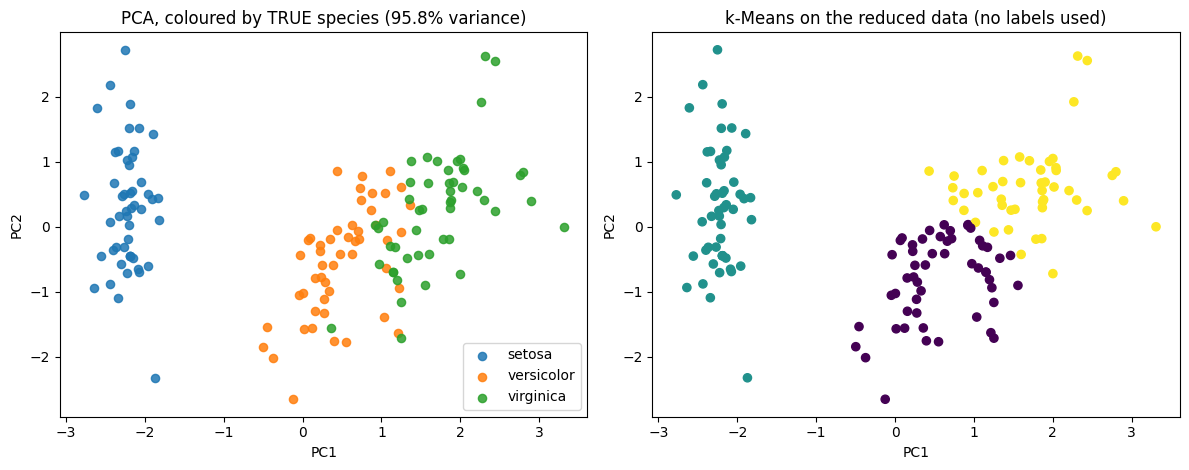

agreement with true species (ARI): 0.6201

High, but not 1.0 - two of the three species genuinely overlap.
NOTE: we can only check this because iris HAPPENS to have labels.
In a real unsupervised problem you would not have that luxury.


In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
for sp in iris.species.unique():
    m = iris.species == sp
    a1.scatter(coords[m, 0], coords[m, 1], s=35, alpha=.85, label=sp)
a1.set_title(f"PCA, coloured by TRUE species ({p.explained_variance_ratio_.sum():.1%} variance)")
a1.legend(); a1.set_xlabel("PC1"); a1.set_ylabel("PC2")

lab = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(coords)
a2.scatter(coords[:, 0], coords[:, 1], c=lab, cmap="viridis", s=35)
a2.set_title("k-Means on the reduced data (no labels used)")
a2.set_xlabel("PC1"); a2.set_ylabel("PC2")
plt.tight_layout(); plt.show()

print("agreement with true species (ARI):", round(adjusted_rand_score(iris.species, lab), 4))
print("\nHigh, but not 1.0 - two of the three species genuinely overlap.")
print("NOTE: we can only check this because iris HAPPENS to have labels.")
print("In a real unsupervised problem you would not have that luxury.")

---
# ✅ Before you move on

- [ ] Unsupervised learning and its three families
- [ ] Why there is no accuracy score here
- [ ] Choosing k with an elbow plot **and** a silhouette curve
- [ ] Profiling and **naming** clusters — the real deliverable
- [ ] What DBSCAN does that k-Means cannot, and when not to use it
- [ ] Having seen a case where the metric prefers the wrong answer
- [ ] **Always plotting your clusters**
- [ ] Support, confidence and lift — and sorting by lift
- [ ] Spotting the high-confidence, lift ≈ 1 trap
- [ ] Reducing to 2-D with PCA and reporting the variance kept

**Exercises, MCQs and tasks:** [Session 7 guide](../sessions/session-07-unsupervised.md)

| | |
|---|---|
| **Previous** | [Session 6 — Augmentation & Feature Engineering](../sessions/session-06-augmentation-feature-engg-red.md) |
| **Next** | [Sessions index](../sessions/README.md) |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |